# Empirical convergence rates

For every numerical method in `numethods`, we plot **error vs. step size** (or vs. iteration count) on a log-log scale. The slope of each line is the empirical order of convergence—and it must match the theoretical order proved in the textbook for the implementation to be correct.

This notebook is the single best evidence that the library is working. Each plot shows:

| Method                         | Theoretical order |
|--------------------------------|-------------------|
| Forward / backward difference  | $\mathcal{O}(h)$ |
| Central difference             | $\mathcal{O}(h^2)$ |
| Richardson extrapolation       | $\mathcal{O}(h^4)$ |
| Trapezoidal rule               | $\mathcal{O}(h^2)$ |
| Simpson's rule                 | $\mathcal{O}(h^4)$ |
| Forward Euler                  | $\mathcal{O}(h)$ |
| RK4                            | $\mathcal{O}(h^4)$ |
| Newton's method                | quadratic (superlinear) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numethods import (
    forward_diff, backward_diff, central_diff, richardson_extrapolation,
    trapezoid, simpson,
    euler, midpoint, rk4,
    newton,
)

plt.rcParams.update({"figure.figsize": (7, 4.5), "figure.dpi": 110, "axes.grid": True})


## Differentiation: $\frac{d}{dx}\sin(x)\big|_{x=1} = \cos(1)$

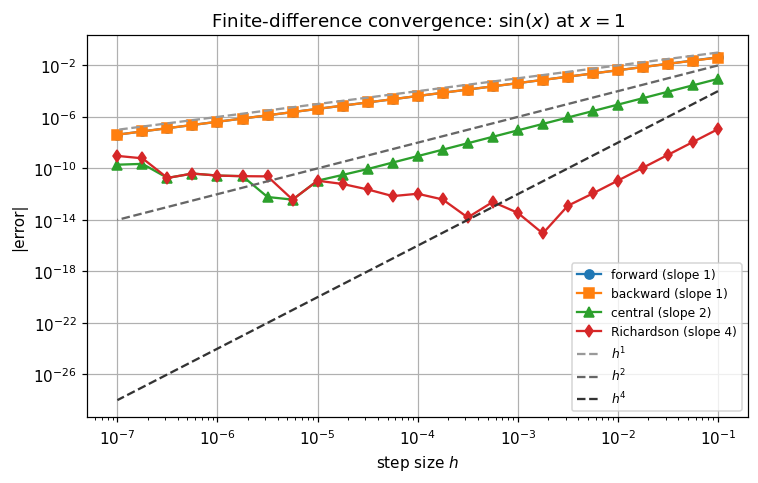

In [2]:
x0 = 1.0
truth = np.cos(x0)
hs = np.logspace(-1, -7, 25)

err_fwd = np.array([abs(forward_diff(np.sin, x0, h) - truth) for h in hs])
err_bwd = np.array([abs(backward_diff(np.sin, x0, h) - truth) for h in hs])
err_ctr = np.array([abs(central_diff(np.sin, x0, h) - truth) for h in hs])
err_rich = np.array([abs(richardson_extrapolation(np.sin, x0, h) - truth) for h in hs])

fig, ax = plt.subplots()
ax.loglog(hs, err_fwd,  "o-", label="forward (slope 1)")
ax.loglog(hs, err_bwd,  "s-", label="backward (slope 1)")
ax.loglog(hs, err_ctr,  "^-", label="central (slope 2)")
ax.loglog(hs, err_rich, "d-", label="Richardson (slope 4)")
ax.loglog(hs, hs,        "--", color="0.6", label="$h^1$")
ax.loglog(hs, hs**2,     "--", color="0.4", label="$h^2$")
ax.loglog(hs, hs**4,     "--", color="0.2", label="$h^4$")
ax.set_xlabel("step size $h$"); ax.set_ylabel("|error|")
ax.set_title(r"Finite-difference convergence: $\sin(x)$ at $x=1$")
ax.legend(loc="lower right", fontsize=8); fig.tight_layout()
plt.show()


The U-shape at very small $h$ is real: subtractive cancellation overwhelms truncation error once $h \lesssim 10^{-5}$.

## Integration: $\int_0^1 e^x\,dx = e - 1$

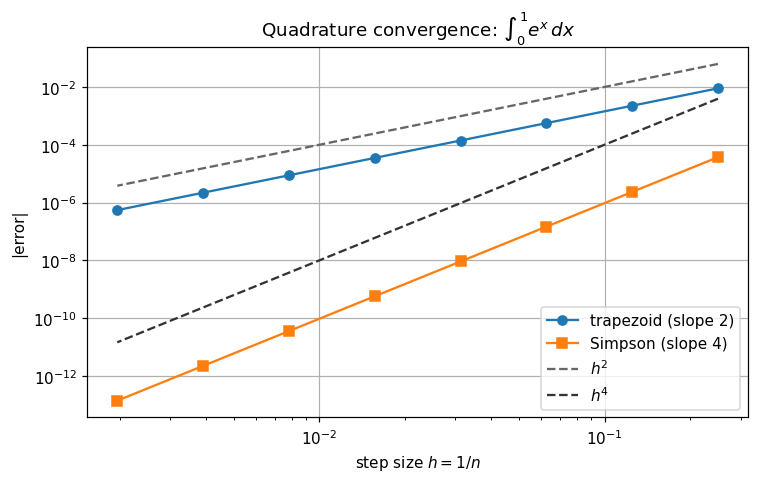

In [3]:
truth = np.e - 1.0
ns = np.array([4, 8, 16, 32, 64, 128, 256, 512])
hs = 1.0 / ns

err_trap = np.array([abs(trapezoid(np.exp, 0, 1, n).value - truth) for n in ns])
err_simp = np.array([abs(simpson(np.exp, 0, 1, n).value - truth) for n in ns])

fig, ax = plt.subplots()
ax.loglog(hs, err_trap, "o-", label="trapezoid (slope 2)")
ax.loglog(hs, err_simp, "s-", label="Simpson (slope 4)")
ax.loglog(hs, hs**2,    "--", color="0.4", label="$h^2$")
ax.loglog(hs, hs**4,    "--", color="0.2", label="$h^4$")
ax.set_xlabel("step size $h = 1/n$"); ax.set_ylabel("|error|")
ax.set_title(r"Quadrature convergence: $\int_0^1 e^x\,dx$")
ax.legend(); fig.tight_layout()
plt.show()


## ODE solvers: $y' = -y,\ y(0) = 1$, exact $y(1) = e^{-1}$

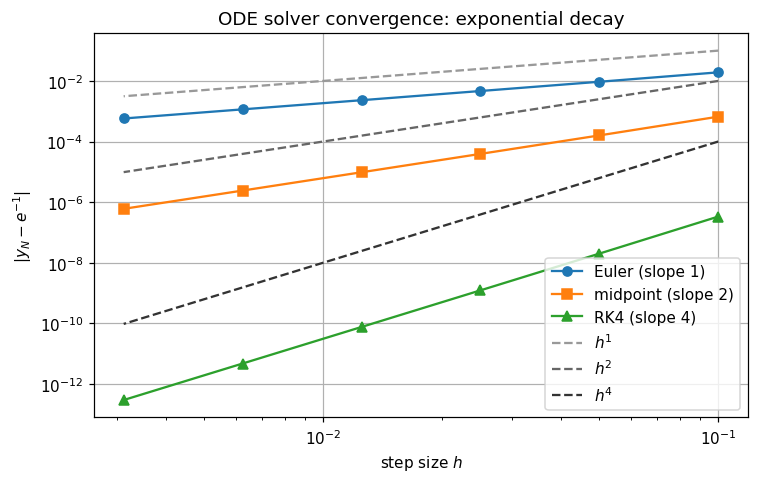

In [4]:
def f(t, y): return -y
truth = np.exp(-1.0)
ns = np.array([10, 20, 40, 80, 160, 320])
hs = 1.0 / ns

err_eul  = np.array([abs(euler(f, (0, 1), 1.0, n).y[-1] - truth) for n in ns])
err_mid  = np.array([abs(midpoint(f, (0, 1), 1.0, n).y[-1] - truth) for n in ns])
err_rk4  = np.array([abs(rk4(f, (0, 1), 1.0, n).y[-1] - truth) for n in ns])

fig, ax = plt.subplots()
ax.loglog(hs, err_eul, "o-", label="Euler (slope 1)")
ax.loglog(hs, err_mid, "s-", label="midpoint (slope 2)")
ax.loglog(hs, err_rk4, "^-", label="RK4 (slope 4)")
ax.loglog(hs, hs,      "--", color="0.6", label="$h^1$")
ax.loglog(hs, hs**2,   "--", color="0.4", label="$h^2$")
ax.loglog(hs, hs**4,   "--", color="0.2", label="$h^4$")
ax.set_xlabel("step size $h$"); ax.set_ylabel(r"$|y_N - e^{-1}|$")
ax.set_title("ODE solver convergence: exponential decay")
ax.legend(); fig.tight_layout()
plt.show()


## Newton's method: quadratic convergence

Plotting $|e_{k+1}|$ versus $|e_k|^2$ should give a straight line through the origin — the signature of quadratic convergence. We solve $x^2 - 2 = 0$ from $x_0 = 2$.

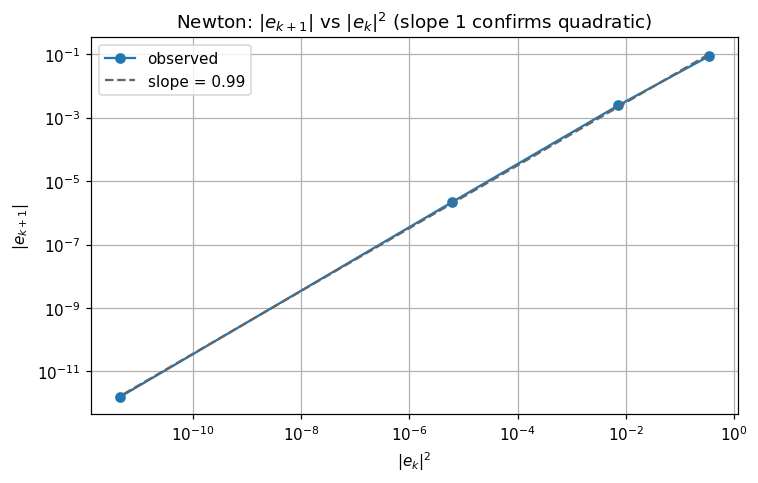

In [5]:
r = newton(lambda x: x**2 - 2, x0=2.0, fprime=lambda x: 2*x)
truth = np.sqrt(2)
errs = np.abs(np.array(r.history) - truth)
errs = errs[errs > 0]

fig, ax = plt.subplots()
ax.loglog(errs[:-1]**2, errs[1:], "o-", label="observed")
slope, intercept = np.polyfit(np.log(errs[:-1]**2), np.log(errs[1:]), 1)
ax.loglog(errs[:-1]**2, np.exp(intercept) * errs[:-1]**(2*slope),
          "--", color="0.4", label=f"slope = {slope:.2f}")
ax.set_xlabel(r"$|e_k|^2$"); ax.set_ylabel(r"$|e_{k+1}|$")
ax.set_title(r"Newton: $|e_{k+1}|$ vs $|e_k|^2$ (slope 1 confirms quadratic)")
ax.legend(); fig.tight_layout()
plt.show()


## Takeaways

- All finite-difference and quadrature rules display the predicted slopes until roundoff dominates near $h \approx 10^{-5}$.
- ODE methods slot neatly at orders 1, 2, and 4.
- Newton's residuals shrink doubly per step — the hallmark of quadratic convergence.

If any of these slopes drifts, the corresponding implementation in `numethods` has a bug. That's why this notebook lives next to the test suite.